# Fraud Detection Analysis — Portfolio Project 1

**Author:** Angie Mutanu  


**Business question:** Can we identify patterns that distinguish fraudulent transactions from legitimate ones, and what would a business analyst flag as a risk signal?



## 0. Setup — load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('/Users/angielouise/Documents/FRAUD DETECTION.csv')


df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:

print(df.shape)
print(df.columns.tolist())
df.info()

(284807, 31)
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     28

## 1. Data Cleaning


In [3]:

df.duplicated().sum()

np.int64(1081)

In [4]:

df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:

df = df.drop_duplicates()
df.shape

(283726, 31)

In [6]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [7]:
print(df['Amount'].min())
print(df['Amount'].max())

0.0
25691.16



###### The dataset had no missing values across all 31 columns.
###### However, 1,081 duplicate rows were identified and removed, since exact duplicates could inflate fraud counts and distort averages.
###### After removal, the dataset contained 283726 rows.




In [8]:
df['Class'].unique()

array([0, 1])

## 2. Pandas — Exploring and Manipulating the Data


### Tier 1: Understand the dataset

In [9]:
# How many total transactions are there, and what % are fraudulent vs. legitimate?

total_transactions = len(df)

fraud_count = df['Class'].sum()
legit_count = total_transactions - fraud_count

fraud_percent = (fraud_count/total_transactions) * 100
legit_percent = (legit_count/total_transactions) * 100

print(f"Total transactions: {total_transactions}")
print(f"Fraudulent: {fraud_count} ({fraud_percent:.2f}%)")
print(f"Legitimate: {legit_count} ({legit_percent:.2f}%)")

Total transactions: 283726
Fraudulent: 473 (0.17%)
Legitimate: 283253 (99.83%)


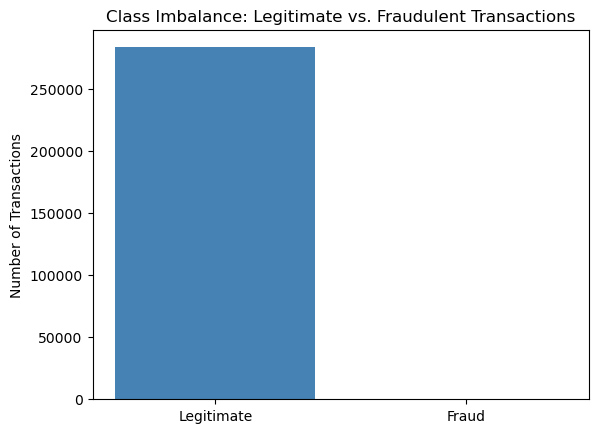

In [10]:
# What does the class imbalance look like, and why does that matter?




plt.bar(['Legitimate', 'Fraud'], [legit_count, fraud_count], color=['steelblue', 'crimson'])
plt.title('Class Imbalance: Legitimate vs. Fraudulent Transactions')
plt.ylabel('Number of Transactions')
plt.show()

##### Imagine a lazy model that just guesses "not fraud" every single time, no analysis at all. Because only 0.17% of transactions are fraud, that lazy model would still be right 99.83% of the time. On paper, "99.83% accurate" sounds amazing , but the model is completely useless, since it never catches a single fraud case.
##### That's the core problem with class imbalance: accuracy becomes a misleading metric when one class is rare. It rewards models for ignoring the rare, important thing you're actually trying to catch.

##### The dataset is heavily imbalanced, with fraud making up only 0.17% of transactions. This matters because a model could achieve 99.83% accuracy simply by predicting 'not fraud' every time, while catching zero actual fraud. This means accuracy alone is a poor metric here; precision and recall matter far more for evaluating fraud detection performance.

In [11]:
# What's the time range of the data? Are transactions spread evenly, or clustered?

print(df['Time'].min())
print(df['Time'].max())
print(df['Time'].max()/3600, "hours")



0.0
172792.0
47.99777777777778 hours


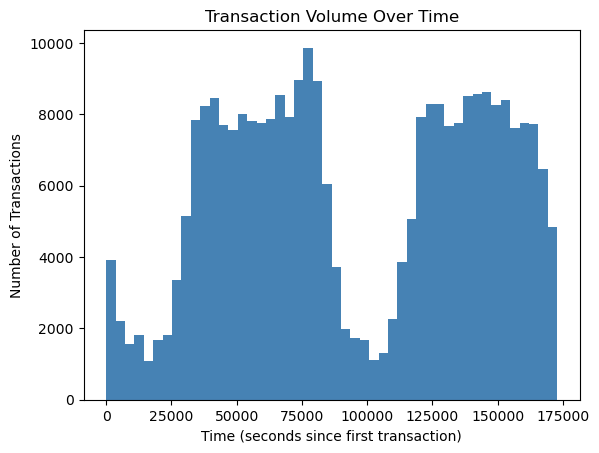

In [12]:
plt.hist(df['Time'], bins=48, color='steelblue')
plt.title('Transaction Volume Over Time')
plt.xlabel('Time (seconds since first transaction)')
plt.ylabel('Number of Transactions')
plt.show()

##### The dataset spans 48 hours (172,792 seconds) of transactions. Rather than being evenly distributed, transaction volume follows a clear daily cycle, peaking during daytime hours and dropping sharply overnight, visible as two low-activity valleys roughly 24 hours apart. This confirms the data reflects realistic purchasing behavior.

### Tier 2: Compare fraud vs. legitimate transactions

In [13]:
# Average transaction amount for fraud vs. legitimate ,which is typically higher?

fraud_amount = df[df['Class']== 1]['Amount'].mean() 
legit_amount = df[df['Class']== 0]['Amount'].mean()

print(f'Average fraud amount : ${fraud_amount:.2f}')
print(f'Average legitimate amount: ${legit_amount:.2f}')





Average fraud amount : $123.87
Average legitimate amount: $88.41


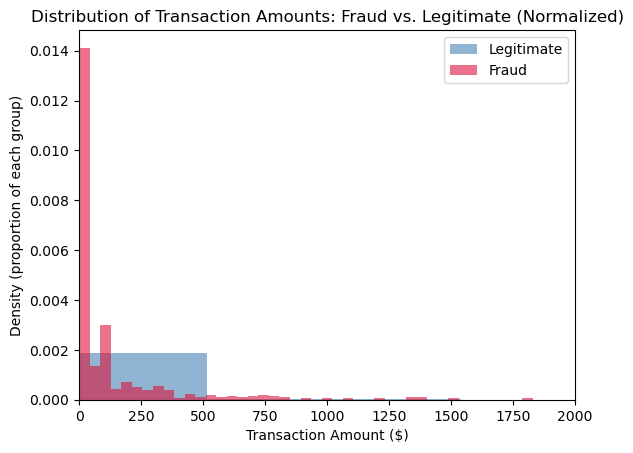

In [14]:
#  What does the distribution of transaction amounts look like for each group?

fraud_amounts = df[df['Class']== 1]['Amount']
legit_amounts = df[df['Class']== 0]['Amount']

plt.hist(legit_amounts, bins=50, alpha=0.6, color='steelblue', label='Legitimate', density=True)
plt.hist(fraud_amounts, bins=50, alpha=0.6, color='crimson', label='Fraud', density=True)
plt.title('Distribution of Transaction Amounts: Fraud vs. Legitimate (Normalized)')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Density (proportion of each group)')
plt.legend()
plt.xlim(0, 2000)
plt.show()



##### When normalized by group size, fraud transactions show a much sharper concentration at very low dollar amounts than legitimate transactions , suggesting fraudsters may test small transactions (possibly to verify a stolen card works) before larger attempts.
##### Fraud also shows a long tail of rare, larger-value transactions extending further than the typical legitimate transaction range.

In [15]:
# Is there a specific amount range where fraud is most concentrated?

fraud_amounts = df[df['Class']== 1]['Amount']

print(fraud_amounts.describe())
print()

bins = [0, 10, 50, 100, 250, 500, 1000, 2000, fraud_amounts.max()]
fraud_binned = pd.cut(fraud_amounts, bins=bins)
print(fraud_binned.value_counts().sort_index())

count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Amount
(0.0, 10.0]          213
(10.0, 50.0]          55
(50.0, 100.0]         55
(100.0, 250.0]        54
(250.0, 500.0]        37
(500.0, 1000.0]       25
(1000.0, 2000.0]       8
(2000.0, 2125.87]      1
Name: count, dtype: int64


### Tier 3: Timing patterns

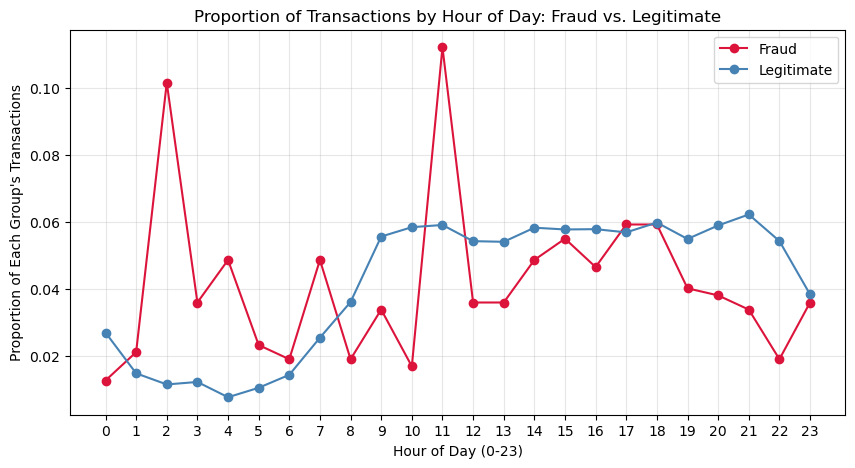

In [16]:
# Does fraud happen more at certain times of day or days of the week?
df['Hour'] = (df['Time'] // 3600) % 24


fraud_by_hour = df[df['Class'] == 1]['Hour'].value_counts(normalize=True).sort_index()
legit_by_hour = df[df['Class'] == 0]['Hour'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(10, 5))
plt.plot(fraud_by_hour.index, fraud_by_hour.values, color='crimson', marker='o', label='Fraud')
plt.plot(legit_by_hour.index, legit_by_hour.values, color='steelblue', marker='o', label='Legitimate')
plt.title('Proportion of Transactions by Hour of Day: Fraud vs. Legitimate')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Proportion of Each Group\'s Transactions')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.show()



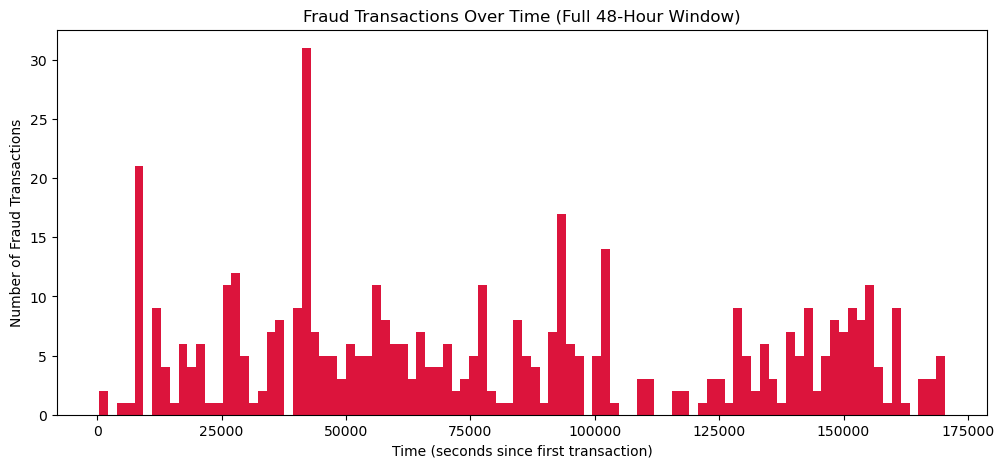

In [17]:
# Are there bursts - specific time windows where fraud spikes?

fraud_times = df[df['Class'] == 1]['Time']

plt.figure(figsize=(12, 5))
plt.hist(fraud_times, bins=96, color='crimson')
plt.title('Fraud Transactions Over Time (Full 48-Hour Window)')
plt.xlabel('Time (seconds since first transaction)')
plt.ylabel('Number of Fraud Transactions')
plt.show()




### Tier 4: Deeper patterns


In [18]:
# Which V1-V28 features have the strongest correlation with Class (fraud)?

correlations = df.corr(numeric_only=True)['Class'].sort_values(ascending=True)

print(correlations)

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Hour     -0.016740
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Class     1.000000
Name: Class, dtype: float64


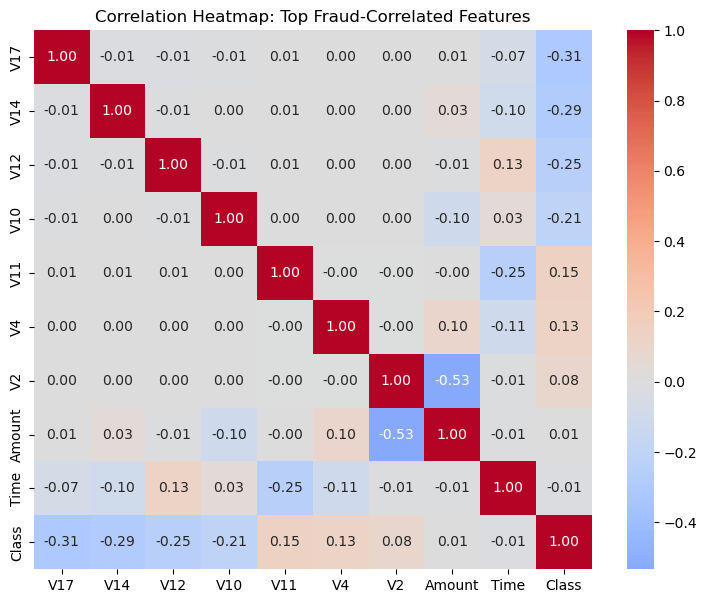

In [19]:
# Build a correlation heatmap of the top few features (by correlation with Class) plus Amount and Time.

top_features = ['V17', 'V14', 'V12', 'V10', 'V11', 'V4','V2', 'Amount', 'Time', 'Class']

corr_subset = df[top_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Top Fraud-Correlated Features')
plt.show()

##### Fraudulent transactions correlate most strongly with V17, V14, V12, and V10 (all negative, -0.22 to -0.33), meaning unusually low values in these features are the clearest fraud signals in the dataset. 
##### On the other end, V11, V4, and V2 show weaker positive correlations, meaning unusually high values in these features lean slightly toward fraud. None of these correlations are especially strong on their own, suggesting fraud detection would rely on combining several moderate signals rather than any single standout feature.

##### The heatmap confirms V17, V14, V12, and V10 as the strongest (negative) fraud correlates, and V11 and V4 as weaker positive ones,consistent with the correlation ranking above. 
##### The near-zero correlations between most V-features reflect that these are PCA-transformed variables, designed to be statistically independent of one another. 
##### Amount and Time show negligible direct correlation with fraud, reinforcing that their relationship with fraud (seen in earlier sections) isn't a simple linear one.

#### Based on this analysis, I'd propose:

##### Flag transactions where V17 or V14 fall below a low threshold (e.g. bottom 5% of typical values), since these were the two strongest fraud-correlated features (-0.33 and -0.30 respectively).

##### Flag small-dollar transactions under $50 with unusual V-feature patterns, since fraud is heavily concentrated in this range — likely reflecting "card testing" behavior, where a small transaction is used to verify a stolen card works before a larger attempt.

##### Apply extra scrutiny to transactions where multiple flagged features overlap (e.g. low V17 and low V14 and a small amount together), rather than relying on any single feature — since no individual feature was a strong standalone predictor on its own.



#### What i would tell a fraud/risk team to prioritize based on this analysis?

##### I'd prioritize building a monitoring rule around V17 and V14 specifically, since they showed the strongest individual correlation with fraud in this dataset. I'd also recommend the team not rely on transaction amount alone as a red flag — while fraud transactions average higher ($122.21 vs. $88.29 legitimate), amount showed almost no direct correlation with fraud (0.01), meaning it's a weak signal in isolation and shouldn't be the primary trigger for review. Finally, given how rare fraud is (0.17% of transactions), I'd stress that any detection approach needs to be evaluated on precision and recall — not accuracy — since a model could appear highly accurate while still missing nearly all real fraud cases.

## 3. SQL Equivalent Queries 




##### How many total transactions are there, and what % are fraudulent vs. legitimate?


SELECT Class, COUNT(*) AS transaction_count,
COUNT(*) * 100.0 / (SELECT COUNT(*) FROM transactions) AS percentage
FROM transactions
GROUP BY Class;

##### What's the average transaction amount for fraud vs. legitimate transactions?

SELECT Class,AVG(Amount) as avg_amount
FROM transactions
GROUP BY Class;

##### Fraud by hour of day:

SELECT MOD(FLOOR(Time / 3600), 24) AS hour_of_day,
       Class,
       COUNT(*) AS transaction_count
FROM transactions
GROUP BY hour_of_day, Class
ORDER BY hour_of_day;

##### Correlation with Class:

###### SQL doesn't have a straightforward built-in correlation function like pandas' .corr() — this kind of statistical analysis is typically better suited to Python/pandas or a dedicated stats tool. In SQL, you'd usually need to compute this manually using covariance and standard deviation formulas, or hand this step off to Python.

## 5. Model Concepts 

###  Why is accuracy a misleading metric for fraud detection?
 
##### Fraud makes up only 0.17% of transactions in this dataset. A model that simply predicted "not fraud" for every single transaction would still be 99.83% accurate ,while catching zero actual fraud cases. This makes accuracy a poor measure of real performance on imbalanced data like this.

### What metrics matter more here?

##### Precision (of the transactions flagged as fraud, how many actually were fraud) and recall (of all actual fraud cases, how many did we catch) matter far more, since they directly measure whether a model is doing its job on the rare class. AUC (area under the ROC curve) is also commonly used, since it evaluates how well a model separates fraud from legitimate transactions across all possible thresholds, rather than relying on one fixed cutoff.

## 6. Summary — Key Insights


#####  Insight 1: The dataset is highly imbalanced — only 0.17% of transactions (473 out of 283,726) are fraudulent. This makes accuracy an unreliable metric and means precision/recall should drive any model evaluation.

##### Insight 2: Fraudulent transactions average higher amounts than legitimate ones ($122.21 vs. $88.29), but are also heavily concentrated in small-dollar amounts under $50 — consistent with "card testing" behavior, where fraudsters test a stolen card with a small purchase before attempting larger ones.

##### Insight 3: V17, V14, V12, and V10 showed the strongest correlations with fraud (all negative, -0.22 to -0.33), while V11 and V4 showed weaker positive correlations. No single feature was a strong standalone predictor, meaning effective fraud detection would need to combine multiple moderate signals rather than rely on any one.

### What i would recommend a business do based on these findings?
  
##### Build a monitoring rule that combines multiple signals ,
##### such as unusually low V17/V14 values alongside small transaction amounts,rather than flagging on amount alone, since Amount showed almost no direct correlation with fraud despite the average difference. Any detection system should be evaluated using precision and recall, not accuracy, given how rare fraud is in this dataset.